# ✈️ Flight Delays and Cancellations | EDA

**Dataset:** [Kaggle - 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays/data)

**Arquivos:**
- `data/raw/flights.csv` → Dados dos voos (5,8M registros)
- `data/raw/airlines.csv` → Dados das companhias aéreas
- `data/raw/airports.csv` → Dados dos aeroportos

## Imports e configurações

In [1]:
# !pip install pyspark matplotlib seaborn pandas numpy

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE_MAIN  = '#2E86AB'
PALETTE_WARN  = '#E84855'
PALETTE_OK    = '#44BBA4'

In [4]:
os.environ['JAVA_HOME'] = "/usr/lib/jvm/java-17-openjdk-amd64"
spark = (
    SparkSession.builder
        .appName("EDA")
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.repl.eagerEval.enabled", True)
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("="*80)
print(f"✅ Spark Session iniciada ...\n\tSpark Version: {spark.version}\n\tPython Version: {sys.version}")
print("="*80)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 12:33:57 WARN Utils: Your hostname, DESKTOP-VMS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/22 12:33:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 12:33:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Session iniciada ...
	Spark Version: 4.1.1
	Python Version: 3.13.5 (main, Jun 11 2025, 15:36:57) [GCC 11.4.0]


## Conhecendo os dados

In [5]:
PATH_FLIGHTS  = '../data/raw/flights.csv'
PATH_AIRLINES = '../data/raw/airlines.csv'
PATH_AIRPORTS = '../data/raw/airports.csv'

In [6]:
df_flights = (
    spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .option('nullValue', 'NA')
    .csv(PATH_FLIGHTS)
)
df_flights.show(5, truncate=False)

26/03/22 12:34:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+--------+---------+-------+-----------------+------------+-------------+--------+---------+-------------------+----------------+--------------+-------------+-------------------+-------------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|FLIGHT_NUMBER|TAIL_NUMBER|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_TIME|DEPARTURE_DELAY|TAXI_OUT|WHEELS_OFF|SCHEDULED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|WHEELS_ON|TAXI_IN|SCHEDULED_ARRIVAL|ARRIVAL_TIME|ARRIVAL_DELAY|DIVERTED|CANCELLED|CANCELLATION_REASON|AIR_SYSTEM_DELAY|SECURITY_DELAY|AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|WEATHER_DELAY|
+----+-----+---+-----------+-------+-------------+-----------+--------------+-------------------+-------------------+--------------+---------------+--------+----------+--------------+------------+--------+-

In [7]:
df_airlines = (
    spark.read
    .option('header', 'true')
    .csv(PATH_AIRLINES)
)
df_airlines.show(5, truncate=False)

+---------+----------------------+
|IATA_CODE|AIRLINE               |
+---------+----------------------+
|UA       |United Air Lines Inc. |
|AA       |American Airlines Inc.|
|US       |US Airways Inc.       |
|F9       |Frontier Airlines Inc.|
|B6       |JetBlue Airways       |
+---------+----------------------+
only showing top 5 rows


In [8]:
df_airports = (
    spark.read
    .option('header', 'true')
    .csv(PATH_AIRPORTS)
)
df_airports.show(5, truncate=False)

+---------+-----------------------------------+-----------+-----+-------+--------+----------+
|IATA_CODE|AIRPORT                            |CITY       |STATE|COUNTRY|LATITUDE|LONGITUDE |
+---------+-----------------------------------+-----------+-----+-------+--------+----------+
|ABE      |Lehigh Valley International Airport|Allentown  |PA   |USA    |40.65236|-75.44040 |
|ABI      |Abilene Regional Airport           |Abilene    |TX   |USA    |32.41132|-99.68190 |
|ABQ      |Albuquerque International Sunport  |Albuquerque|NM   |USA    |35.04022|-106.60919|
|ABR      |Aberdeen Regional Airport          |Aberdeen   |SD   |USA    |45.44906|-98.42183 |
|ABY      |Southwest Georgia Regional Airport |Albany     |GA   |USA    |31.53552|-84.19447 |
+---------+-----------------------------------+-----------+-----+-------+--------+----------+
only showing top 5 rows


In [9]:
# Colunas df_flights
dicionario = {
    'YEAR'                    : 'Ano do voo (2015)',
    'MONTH'                   : 'Mês (1-12)',
    'DAY'                     : 'Dia do mês',
    'DAY_OF_WEEK'             : 'Dia da semana (1=Seg, 7=Dom)',
    'AIRLINE'                 : 'Código IATA da companhia',
    'FLIGHT_NUMBER'           : 'Número do voo',
    'TAIL_NUMBER'             : 'Matrícula da aeronave',
    'ORIGIN_AIRPORT'          : 'Aeroporto de origem (IATA)',
    'DESTINATION_AIRPORT'     : 'Aeroporto de destino (IATA)',
    'SCHEDULED_DEPARTURE'     : 'Partida programada (HHMM)',
    'DEPARTURE_TIME'          : 'Partida real (HHMM)',
    'DEPARTURE_DELAY'         : 'Atraso na partida (min)',
    'TAXI_OUT'                : 'Tempo até decolar após sair do portão (min)',
    'WHEELS_OFF'              : 'Hora que as rodas saíram do chão',
    'SCHEDULED_TIME'          : 'Duração programada do voo (min)',
    'ELAPSED_TIME'            : 'Duração real do voo (min)',
    'AIR_TIME'                : 'Tempo no ar (min)',
    'DISTANCE'                : 'Distância da rota (milhas)',
    'WHEELS_ON'               : 'Hora que as rodas tocaram o chão',
    'TAXI_IN'                 : 'Tempo do pouso até o portão (min)',
    'SCHEDULED_ARRIVAL'       : 'Chegada programada (HHMM)',
    'ARRIVAL_TIME'            : 'Chegada real (HHMM)',
    'ARRIVAL_DELAY'           : 'Atraso na chegada (min; neg = adiantado)[TARGET]',
    'DIVERTED'                : 'Voo desviado (1=Sim)',
    'CANCELLED'               : 'Voo cancelado (1=Sim)',
    'CANCELLATION_REASON'     : 'Motivo: A=Cia, B=Tempo, C=NAS, D=Segurança',
    'AIR_SYSTEM_DELAY'        : 'Atraso por sistema aéreo (min)',
    'SECURITY_DELAY'          : 'Atraso por segurança (min)',
    'AIRLINE_DELAY'           : 'Atraso por culpa da Cia (min)',
    'LATE_AIRCRAFT_DELAY'     : 'Atraso por aeronave atrasada (min)',
    'WEATHER_DELAY'           : 'Atraso por condições climáticas (min)',
}
pd.DataFrame.from_dict(dicionario, orient='index', columns=['Descrição'])

,Descrição
YEAR,Ano do voo (2015)
MONTH,Mês (1-12)
DAY,Dia do mês
DAY_OF_WEEK,"Dia da semana (1=Seg, 7=Dom)"
AIRLINE,Código IATA da companhia
FLIGHT_NUMBER,Número do voo
TAIL_NUMBER,Matrícula da aeronave
ORIGIN_AIRPORT,Aeroporto de origem (IATA)
DESTINATION_AIRPORT,Aeroporto de destino (IATA)
SCHEDULED_DEPARTURE,Partida programada (HHMM)


In [10]:
print("="*80)
print("Conhecendo os dados:")

row_count = df_flights.count()
col_count = len(df_flights.columns)
cancelled_flights = df_flights.filter(F.col("CANCELLED") == 1).count()
diverted_flights = df_flights.filter(F.col("DIVERTED") == 1).count()
delayed_flights = df_flights.filter(F.col("ARRIVAL_DELAY") > 0).count()

print(f"O arquivo {PATH_FLIGHTS} possui {row_count} linhas e {col_count} colunas.")
print(f"Cada linha representa um voo registrado pelo DOT (Department of Transportation) dos EUA,\ne contém informações como data, horário, origem, destino, companhia aérea, número do voo, status de cancelamento, desvio e atraso.")
print(f"Desse total de voos, temos:")
print(f"\t - {cancelled_flights:,} voos foram cancelados".replace(',', '.'))
print(f"\t - {diverted_flights:,} voos foram desviados".replace(',', '.'))
print(f"\t - {delayed_flights:,} voos tiveram atraso".replace(',', '.'))
print("="*80)

Conhecendo os dados:


O arquivo ../data/raw/flights.csv possui 5819079 linhas e 31 colunas.
Cada linha representa um voo registrado pelo DOT (Department of Transportation) dos EUA,
e contém informações como data, horário, origem, destino, companhia aérea, número do voo, status de cancelamento, desvio e atraso.
Desse total de voos, temos:
	 - 89.884 voos foram cancelados
	 - 15.187 voos foram desviados
	 - 2.086.896 voos tiveram atraso


In [11]:
print("="*80)
print("Tipos de dados e valores nulos:")
null_counts = df_flights.select([F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df_flights.columns]).collect()[0].asDict()
flight_info_data = []
for col_name in df_flights.columns:
    col_type = dict(df_flights.dtypes)[col_name]
    null_count = null_counts[col_name]
    null_pct = round((null_count / row_count) * 100, 2)
    flight_info_data.append((col_name, col_type, null_count, null_pct))

flight_info = spark.createDataFrame(flight_info_data, ["Coluna", "Tipo", "Nulos", "Nulos (%)"]).orderBy(F.desc("Nulos (%)"))
flight_info.show(truncate=False)
print("="*80)

Tipos de dados e valores nulos:


+-------------------+------+-------+---------+
|Coluna             |Tipo  |Nulos  |Nulos (%)|
+-------------------+------+-------+---------+
|CANCELLATION_REASON|string|5729195|98.46    |
|LATE_AIRCRAFT_DELAY|int   |4755640|81.72    |
|SECURITY_DELAY     |int   |4755640|81.72    |
|WEATHER_DELAY      |int   |4755640|81.72    |
|AIR_SYSTEM_DELAY   |int   |4755640|81.72    |
|AIRLINE_DELAY      |int   |4755640|81.72    |
|ARRIVAL_DELAY      |int   |105071 |1.81     |
|ELAPSED_TIME       |int   |105071 |1.81     |
|AIR_TIME           |int   |105071 |1.81     |
|ARRIVAL_TIME       |int   |92513  |1.59     |
|TAXI_IN            |int   |92513  |1.59     |
|WHEELS_ON          |int   |92513  |1.59     |
|WHEELS_OFF         |int   |89047  |1.53     |
|TAXI_OUT           |int   |89047  |1.53     |
|DEPARTURE_TIME     |int   |86153  |1.48     |
|DEPARTURE_DELAY    |int   |86153  |1.48     |
|TAIL_NUMBER        |string|14721  |0.25     |
|YEAR               |int   |0      |0.0      |
|ORIGIN_AIRPO

## Variável-Alvo: `ARRIVAL_DELAY`

> **Nota:** Consideraremos um voo "atrasado" quando `ARRIVAL_DELAY > 15 minutos`,
> alinhado ao critério oficial do DOT (Departamento de Transportes dos EUA).
> Cancelamentos e desvios serão tratados separadamente.

In [12]:
df_flights.select('ARRIVAL_DELAY').describe().toPandas()

,summary,ARRIVAL_DELAY
0,count,5714008
1,mean,4.407057357987598
2,stddev,39.27129709388639
3,min,-87
4,max,1971


In [13]:
# Distribuição das classes

df_validos = df_flights.filter(
    (F.col('CANCELLED') == 0) &
    (F.col('DIVERTED')  == 0) &
    (F.col('ARRIVAL_DELAY').isNotNull())
)

df_classe = df_validos.withColumn(
    'ATRASADO',
    F.when(F.col('ARRIVAL_DELAY') > 15, 1).otherwise(0)
)

classe_dist = (
    df_classe.groupBy('ATRASADO')
    .count()
    .withColumn('PERCENTUAL', F.round(F.col('count') / row_count * 100, 2))
    .orderBy('ATRASADO')
    .toPandas()
)

classe_dist['LABEL'] = classe_dist['ATRASADO'].map({0: 'Não atrasado (ARRIVAL_DELAY ≤ 15 min)', 1: 'Atrasado (ARRIVAL_DELAY >15 min)'})
print(classe_dist[['LABEL','count','PERCENTUAL']].to_string(index=False))

                                LABEL   count  PERCENTUAL
Não atrasado (ARRIVAL_DELAY ≤ 15 min) 4690510       80.61
     Atrasado (ARRIVAL_DELAY >15 min) 1023498       17.59


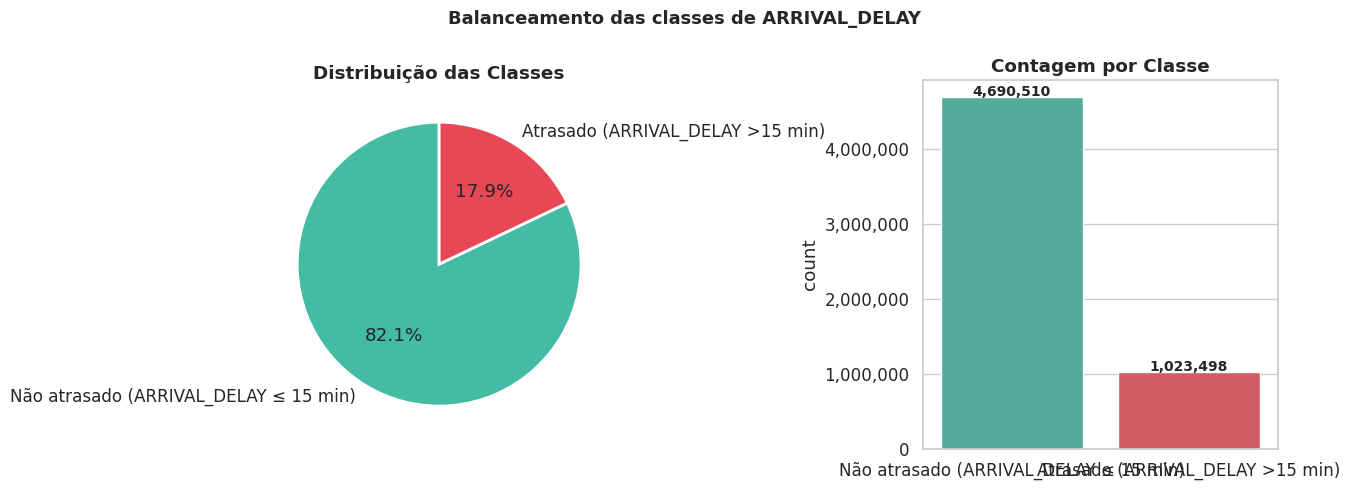

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
colors = [PALETTE_OK, PALETTE_WARN]
axes[0].pie(
    classe_dist['count'],
    labels=classe_dist['LABEL'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribuição das Classes', fontweight='bold')

# Barras
sns.barplot(
    data=classe_dist, x='LABEL', y='count',
    palette=colors, ax=axes[1], edgecolor='white'
)
for bar, val in zip(axes[1].patches, classe_dist['count']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20000,
        f'{val:,}', ha='center', fontsize=10, fontweight='bold'
    )
axes[1].set_title('Contagem por Classe', fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Balanceamento das classes de ARRIVAL_DELAY', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Importante:** Foi identificado um desbalanceamento significativo entre as classes atrasado e não atrasado.

## Nulos

In [15]:
nulos = (
    df_flights
    .select([
        F.sum(F.col(c).isNull().cast('int')).alias(c)
        for c in df_flights.columns
    ])
    .toPandas()
    .T
    .rename(columns={0: 'NULOS'})
    .assign(PERCENTUAL=lambda df: (df['NULOS'] / row_count * 100).round(2))
    .sort_values('PERCENTUAL', ascending=False)
)

nulos_sig = nulos[nulos['NULOS'] > 0].copy()
print(f'Colunas com valores nulos: {len(nulos_sig)} / {len(nulos)}')
print()
print(nulos_sig.to_string())

Colunas com valores nulos: 18 / 31

                       NULOS  PERCENTUAL
CANCELLATION_REASON  5729195       98.46
LATE_AIRCRAFT_DELAY  4755640       81.72
WEATHER_DELAY        4755640       81.72
AIRLINE_DELAY        4755640       81.72
AIR_SYSTEM_DELAY     4755640       81.72
SECURITY_DELAY       4755640       81.72
ELAPSED_TIME          105071        1.81
AIR_TIME              105071        1.81
ARRIVAL_DELAY         105071        1.81
WHEELS_ON              92513        1.59
TAXI_IN                92513        1.59
ARRIVAL_TIME           92513        1.59
WHEELS_OFF             89047        1.53
TAXI_OUT               89047        1.53
DEPARTURE_TIME         86153        1.48
DEPARTURE_DELAY        86153        1.48
TAIL_NUMBER            14721        0.25
SCHEDULED_TIME             6        0.00


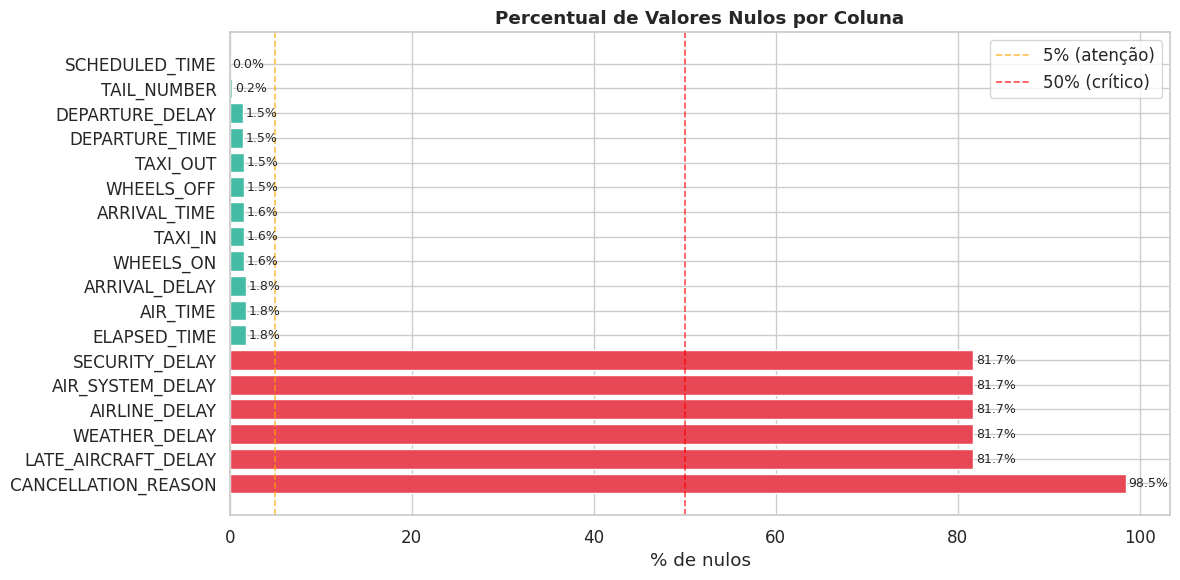

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_bar = [
    PALETTE_WARN if p > 50 else PALETTE_MAIN if p > 5 else PALETTE_OK
    for p in nulos_sig['PERCENTUAL']
]

bars = ax.barh(nulos_sig.index, nulos_sig['PERCENTUAL'], color=colors_bar, edgecolor='white')

for bar, pct in zip(bars, nulos_sig['PERCENTUAL']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%', va='center', fontsize=9
    )

ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label='5% (atenção)')
ax.axvline(50, color='red',    linestyle='--', linewidth=1.2, alpha=0.7, label='50% (crítico)')
ax.set_title('Percentual de Valores Nulos por Coluna', fontweight='bold')
ax.set_xlabel('% de nulos')
ax.legend()
plt.tight_layout()
plt.show()


## Padrões Temporais

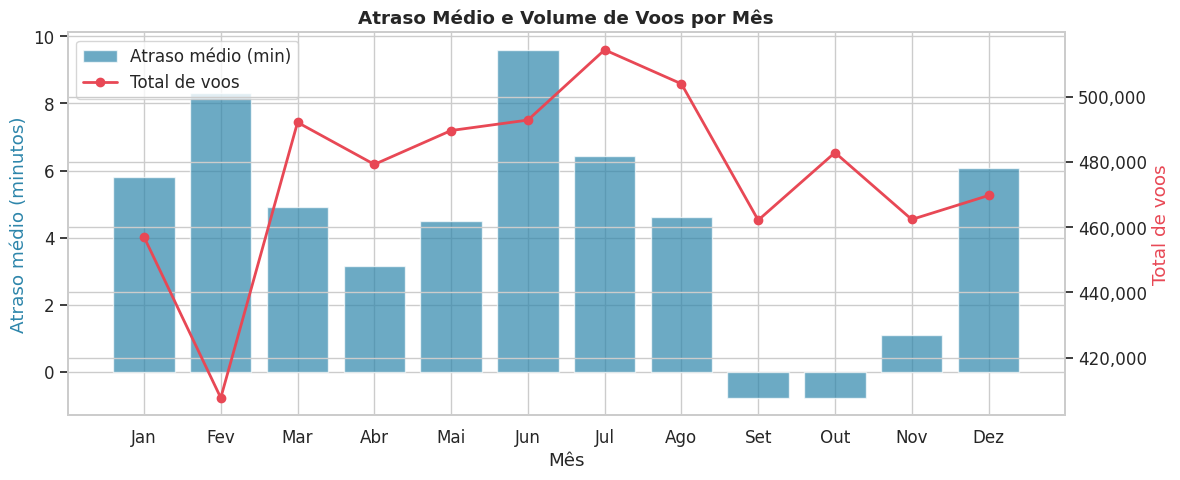

In [17]:
# Atraso médio mensal
atraso_mes = (
    df_validos
    .groupBy('MONTH')
    .agg(
        F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'),
        F.count('*').alias('TOTAL_VOOS')
    )
    .orderBy('MONTH')
    .toPandas()
)

meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
atraso_mes['MES_NOME'] = atraso_mes['MONTH'].apply(lambda x: meses_label[x-1])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(atraso_mes['MES_NOME'], atraso_mes['ATRASO_MEDIO'],
        color=PALETTE_MAIN, alpha=0.7, label='Atraso médio (min)')
ax2.plot(atraso_mes['MES_NOME'], atraso_mes['TOTAL_VOOS'],
        color=PALETTE_WARN, marker='o', linewidth=2, label='Total de voos')

ax1.set_xlabel('Mês')
ax1.set_ylabel('Atraso médio (minutos)', color=PALETTE_MAIN)
ax2.set_ylabel('Total de voos', color=PALETTE_WARN)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Atraso Médio e Volume de Voos por Mês', fontweight='bold')

plt.tight_layout()
plt.show()

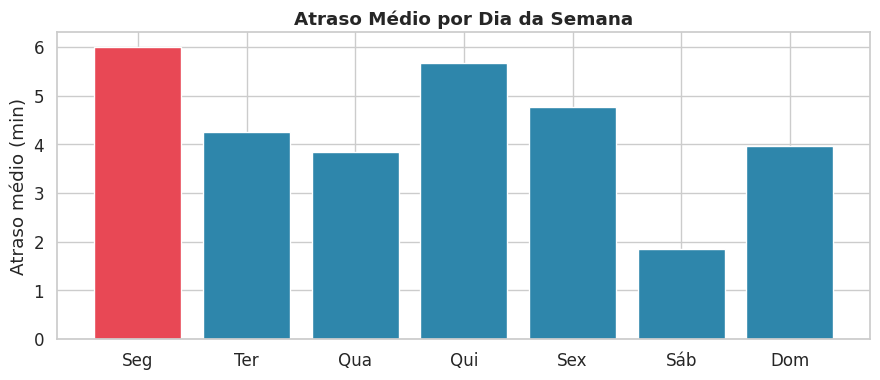

In [18]:
#  Atraso médio semanal
atraso_dow = (
    df_validos
    .groupBy('DAY_OF_WEEK')
    .agg(F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'))
    .orderBy('DAY_OF_WEEK')
    .toPandas()
)

dias_label = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
atraso_dow['DIA_NOME'] = atraso_dow['DAY_OF_WEEK'].apply(lambda x: dias_label[x-1])

fig, ax = plt.subplots(figsize=(9, 4))
palette = [PALETTE_WARN 
        if v == atraso_dow['ATRASO_MEDIO'].max() 
        else PALETTE_MAIN
        for v in atraso_dow['ATRASO_MEDIO']]
ax.bar(atraso_dow['DIA_NOME'], atraso_dow['ATRASO_MEDIO'], color=palette, edgecolor='white')
ax.set_title('Atraso Médio por Dia da Semana', fontweight='bold')
ax.set_ylabel('Atraso médio (min)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

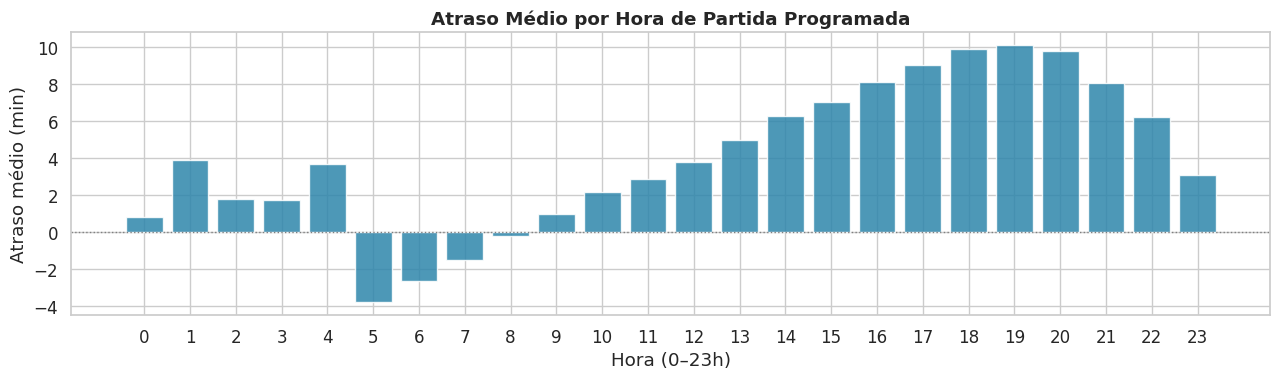

In [19]:
# Atraso médio por faixa de horário
atraso_hora = (
    df_validos
    .withColumn('HORA_PARTIDA', (F.col('SCHEDULED_DEPARTURE') / 100).cast('int'))
    .groupBy('HORA_PARTIDA')
    .agg(F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'))
    .filter(F.col('HORA_PARTIDA').between(0, 23))
    .orderBy('HORA_PARTIDA')
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(atraso_hora['HORA_PARTIDA'], atraso_hora['ATRASO_MEDIO'],
    color=PALETTE_MAIN, alpha=0.85, edgecolor='white')
ax.axhline(0, color='gray', linewidth=1, linestyle=':')
ax.set_title('Atraso Médio por Hora de Partida Programada', fontweight='bold')
ax.set_xlabel('Hora (0–23h)')
ax.set_ylabel('Atraso médio (min)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Companhia Aérea

In [20]:
atraso_airline = (
    df_validos
    .groupBy('AIRLINE')
    .agg(
        F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'),
        F.round(
            F.sum((F.col('ARRIVAL_DELAY') > 15).cast('int')) / F.count('*') * 100, 2
        ).alias('PCT_ATRASADO'),
        F.count('*').alias('TOTAL_VOOS')
    )
    .join(
        df_airlines.withColumnRenamed('AIRLINE', 'NOME').withColumnRenamed('IATA_CODE', 'AIRLINE'),
        on='AIRLINE', how='left'
    )
    .orderBy('ATRASO_MEDIO', ascending=False)
    .toPandas()
)

print(atraso_airline[['NOME','TOTAL_VOOS','ATRASO_MEDIO','PCT_ATRASADO']].to_string(index=False))

                        NOME  TOTAL_VOOS  ATRASO_MEDIO  PCT_ATRASADO
            Spirit Air Lines      115193         14.47         28.79
      Frontier Airlines Inc.       90090         12.50         25.36
             JetBlue Airways      262042          6.68         21.85
 Atlantic Southeast Airlines      554752          6.59         18.99
American Eagle Airlines Inc.      278791          6.46         21.03
       Skywest Airlines Inc.      576814          5.85         18.00
       United Air Lines Inc.      507762          5.43         19.95
              Virgin America       61248          4.74         18.53
      Southwest Airlines Co.     1242403          4.37         18.30
             US Airways Inc.      194223          3.71         17.98
      American Airlines Inc.      712935          3.45         17.57
      Hawaiian Airlines Inc.       76041          2.02         10.53
        Delta Air Lines Inc.      870275          0.19         13.00
        Alaska Airlines Inc.      

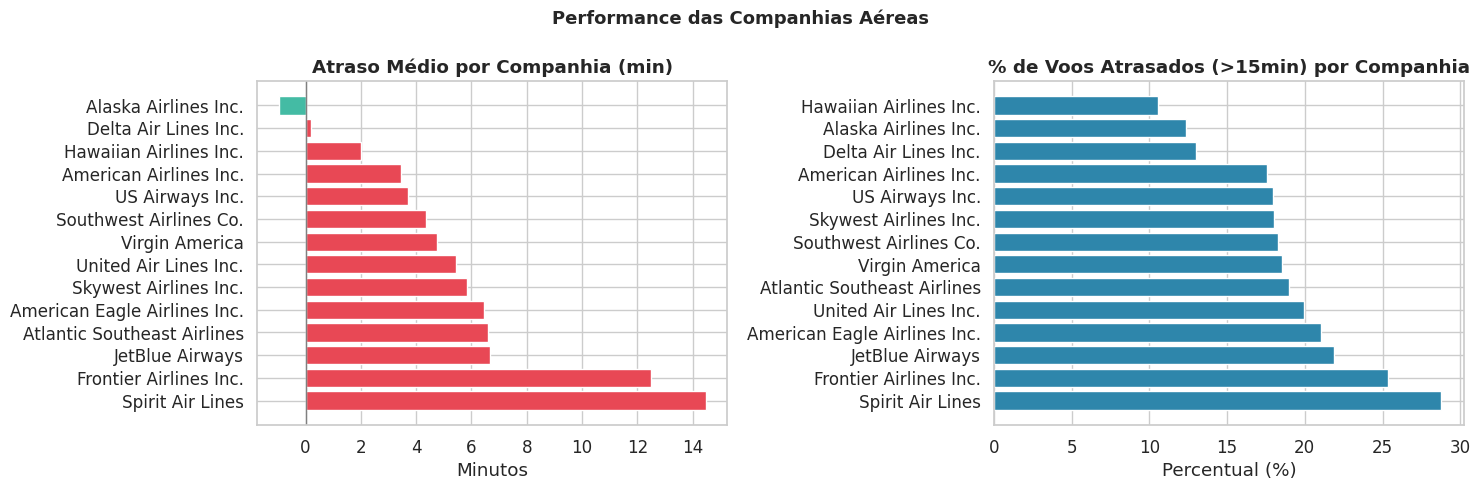

In [21]:
# ── Gráfico: companhias por atraso médio e % de voos atrasados ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Atraso médio
colors_bar = [PALETTE_WARN if v > 0 else PALETTE_OK for v in atraso_airline['ATRASO_MEDIO']]
axes[0].barh(atraso_airline['NOME'], atraso_airline['ATRASO_MEDIO'],
            color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='gray', linewidth=1)
axes[0].set_title('Atraso Médio por Companhia (min)', fontweight='bold')
axes[0].set_xlabel('Minutos')

# % de voos atrasados
axes[1].barh(atraso_airline.sort_values('PCT_ATRASADO', ascending=False)['NOME'],
            atraso_airline.sort_values('PCT_ATRASADO', ascending=False)['PCT_ATRASADO'],
            color=PALETTE_MAIN, edgecolor='white')
axes[1].set_title('% de Voos Atrasados (>15min) por Companhia', fontweight='bold')
axes[1].set_xlabel('Percentual (%)')

plt.suptitle('Performance das Companhias Aéreas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Aeroporto

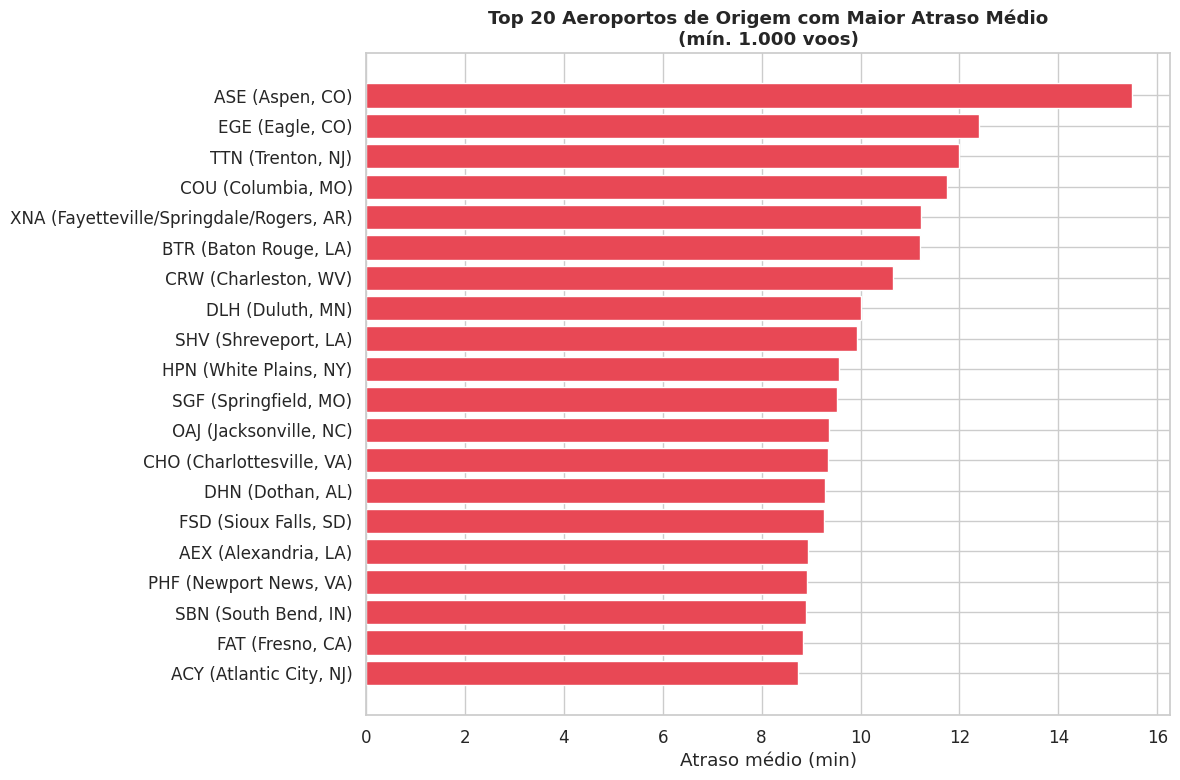

In [22]:
atraso_origem = (
    df_validos
    .groupBy('ORIGIN_AIRPORT')
    .agg(
        F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'),
        F.count('*').alias('TOTAL_VOOS')
    )
    .filter(F.col('TOTAL_VOOS') > 1000)   # mínimo de voos para relevância estatística
    .orderBy('ATRASO_MEDIO', ascending=False)
    .limit(20)
    .join(
        df_airports
            .withColumnRenamed('IATA_CODE', 'ORIGIN_AIRPORT')
            .select('ORIGIN_AIRPORT', 'CITY', 'STATE'),
        on='ORIGIN_AIRPORT', how='left'
    )
    .toPandas()
)

atraso_origem['LABEL'] = (
    atraso_origem['ORIGIN_AIRPORT'] + ' (' +
    atraso_origem['CITY'].fillna('') + ', ' +
    atraso_origem['STATE'].fillna('') + ')'
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(atraso_origem['LABEL'][::-1], atraso_origem['ATRASO_MEDIO'][::-1],
        color=PALETTE_WARN, edgecolor='white')
ax.set_title('Top 20 Aeroportos de Origem com Maior Atraso Médio\n(mín. 1.000 voos)', fontweight='bold')
ax.set_xlabel('Atraso médio (min)')
plt.tight_layout()
plt.show()

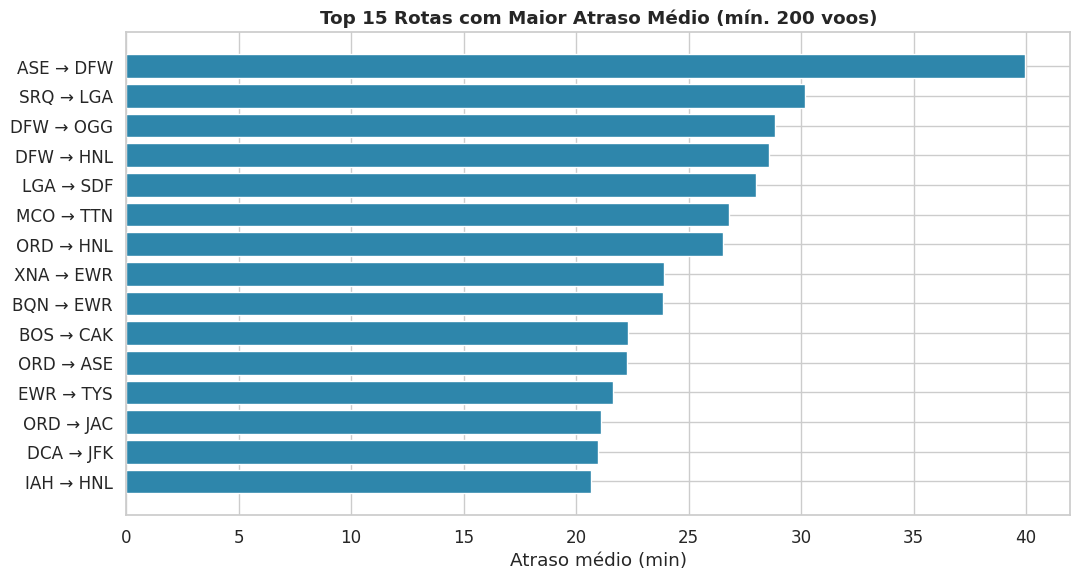

In [23]:
# Rotas (origem → destino) com maior atraso total
atraso_rota = (
    df_validos
    .withColumn('ROTA', F.concat(
        F.col('ORIGIN_AIRPORT'), F.lit(' → '), F.col('DESTINATION_AIRPORT')
    ))
    .groupBy('ROTA')
    .agg(
        F.round(F.mean('ARRIVAL_DELAY'), 2).alias('ATRASO_MEDIO'),
        F.count('*').alias('TOTAL_VOOS')
    )
    .filter(F.col('TOTAL_VOOS') > 200)
    .orderBy('ATRASO_MEDIO', ascending=False)
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(atraso_rota['ROTA'][::-1], atraso_rota['ATRASO_MEDIO'][::-1],
        color=PALETTE_MAIN, edgecolor='white')
ax.set_title('Top 15 Rotas com Maior Atraso Médio (mín. 200 voos)', fontweight='bold')
ax.set_xlabel('Atraso médio (min)')
plt.tight_layout()
plt.show()

## Tipos de atraso

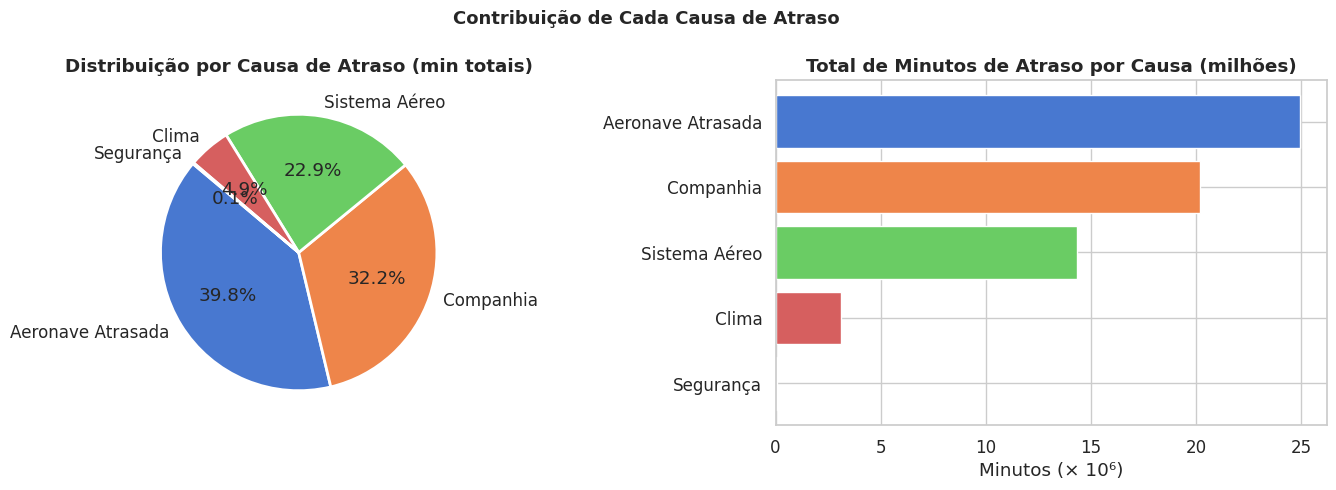

                   TOTAL_MIN  PERCENTUAL
Aeronave Atrasada   24961931       39.84
Companhia           20172956       32.20
Sistema Aéreo       14335762       22.88
Clima                3100233        4.95
Segurança              80985        0.13


In [24]:
# ── Contribuição de cada causa de atraso ─────────────────────────────────────
causas = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
        'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

causas_total = (
    df_validos
    .agg(*[F.round(F.sum(F.coalesce(F.col(c), F.lit(0))), 0).alias(c) for c in causas])
    .toPandas()
    .T
    .rename(columns={0: 'TOTAL_MIN'})
    .sort_values('TOTAL_MIN', ascending=False)
)

causas_total['PERCENTUAL'] = (causas_total['TOTAL_MIN'] / causas_total['TOTAL_MIN'].sum() * 100).round(2)

LABELS_PT = {
    'AIR_SYSTEM_DELAY'  : 'Sistema Aéreo',
    'SECURITY_DELAY'    : 'Segurança',
    'AIRLINE_DELAY'     : 'Companhia',
    'LATE_AIRCRAFT_DELAY': 'Aeronave Atrasada',
    'WEATHER_DELAY'     : 'Clima',
}
causas_total.index = causas_total.index.map(LABELS_PT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_causas = sns.color_palette('muted', len(causas_total))
axes[0].pie(
    causas_total['TOTAL_MIN'],
    labels=causas_total.index,
    autopct='%1.1f%%',
    colors=palette_causas,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribuição por Causa de Atraso (min totais)', fontweight='bold')

axes[1].barh(causas_total.index[::-1], causas_total['TOTAL_MIN'][::-1] / 1e6,
            color=palette_causas[::-1], edgecolor='white')
axes[1].set_title('Total de Minutos de Atraso por Causa (milhões)', fontweight='bold')
axes[1].set_xlabel('Minutos (× 10⁶)')

plt.suptitle('Contribuição de Cada Causa de Atraso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(causas_total.to_string())

## Voo cancelados e desviados

In [25]:
status = (
    df_flights
    .agg(
        F.sum('CANCELLED').alias('CANCELADOS'),
        F.sum('DIVERTED').alias('DESVIADOS'),
        F.count('*').alias('TOTAL')
    )
    .toPandas()
)

print(f"Total de voos: {int(status['TOTAL'][0]):,}")
print(f"Cancelados:    {int(status['CANCELADOS'][0]):,} ({status['CANCELADOS'][0]/status['TOTAL'][0]*100:.2f}%)")
print(f"Desviados:     {int(status['DESVIADOS'][0]):,} ({status['DESVIADOS'][0]/status['TOTAL'][0]*100:.2f}%)")

Total de voos: 5,819,079
Cancelados:    89,884 (1.54%)
Desviados:     15,187 (0.26%)


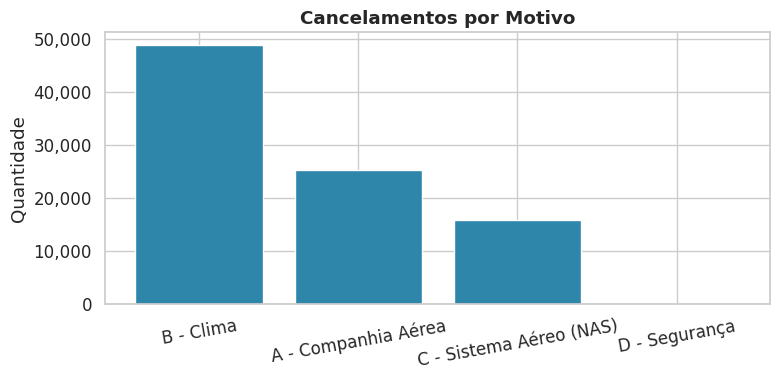

In [26]:
motivos = (
    df_flights
    .filter(F.col('CANCELLED') == 1)
    .groupBy('CANCELLATION_REASON')
    .count()
    .toPandas()
)

motivos_map = {
    'A': 'A - Companhia Aérea',
    'B': 'B - Clima',
    'C': 'C - Sistema Aéreo (NAS)',
    'D': 'D - Segurança',
}
motivos['LABEL'] = motivos['CANCELLATION_REASON'].map(motivos_map).fillna('Desconhecido')
motivos = motivos.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(motivos['LABEL'], motivos['count'], color=PALETTE_MAIN, edgecolor='white')
ax.set_title('Cancelamentos por Motivo', fontweight='bold')
ax.set_ylabel('Quantidade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Correlações

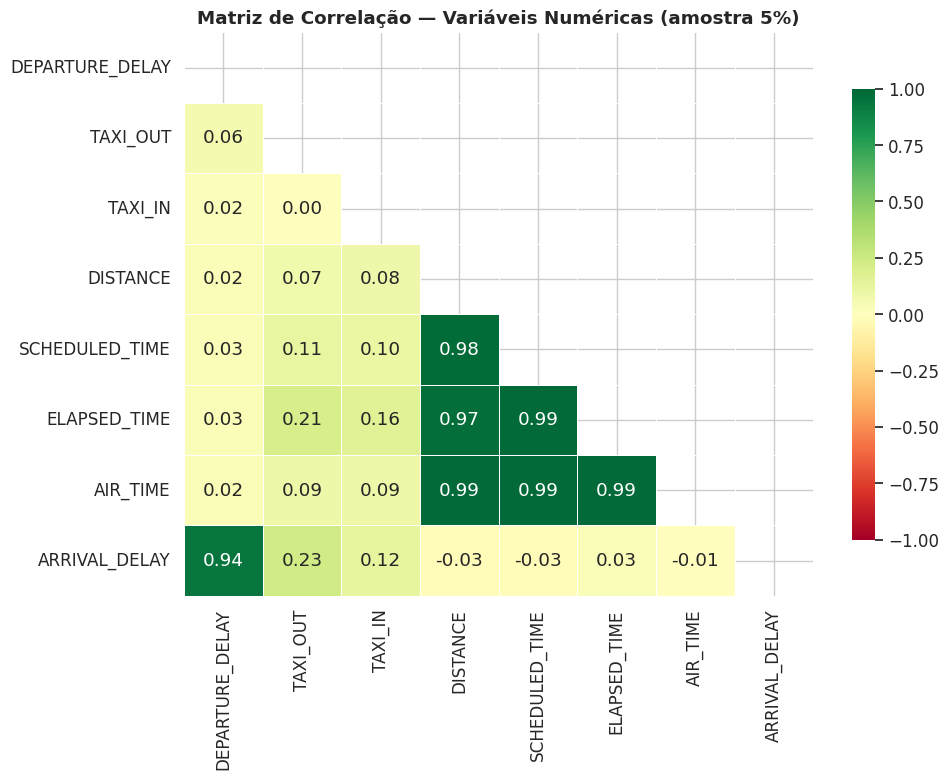

In [27]:
cols_corr = [
    'DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN', 'DISTANCE',
    'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'ARRIVAL_DELAY'
]

df_corr = (
    df_validos
    .select(cols_corr)
    .dropna()
    .sample(fraction=0.05, seed=42)
    .toPandas()
)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas (amostra 5%)', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusões


| Observação | Impacto | Correção |
|---|---|---|
| Classes desbalanceadas | Modelo enviesado para a classe Não Atrasado | Aplicar técnicas para o balanceamento das classes |
| `DEPARTURE_DELAY` é fortemente correlacionada com `ARRIVAL_DELAY` | Risco de data leakage | Criar nova feature |
| Colunas de causa de atraso com ~60% de nulos | Nulos são **informativos** (sem atraso = sem causa) | Preencher com 0 para voos não atrasados |
| Efeito bola de neve no horário | Padrão temporal forte | Criar nova feature |
| Variação significativa entre companhias | Sinal preditivo importante | Encoding por companhia |
| Cancelados/desviados sem `ARRIVAL_DELAY` | Subconjunto diferente | Não forncecer esses registros para o modelo |
